# OpenDataBattle2026 Phase2 データ加工【水】

#### [1]読み込み
#### [2]前処理

## 【読み込み】

### ライブラリ読み込み

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### データ読み込み

In [2]:
# 県庁所在地一覧
df_prefectural_capitals = pd.read_csv("../data/raw_00_reference_県庁所在地一覧_20260803.csv", encoding='shift_jis')

# 水源データ
df_water_source = pd.read_csv("../data/raw_01_water_県庁所在地別水源データ_20260915.csv")
# 硬度・pHデータ
df_water_quality = pd.read_csv("../data/raw_01_water_県庁所在地別水道水硬度pHデータ_20260826.csv", encoding='shift_jis')

# 行政区域データ → Python3.12環境で作業
#gdf = gpd.read_file("../data/GIS_行政区域データ_20260803/N03-23_230101.shp")
# BOD・CODデータ → Python3.12環境で作業
#df_water_cleanliness = pd.read_csv("../data/raw_01_water_公共用水域水質測定データ_20260803.csv", encoding='shift_jis')

C:\Users\kumas\AppData\Local\Temp\ipykernel_4316\1320837811.py:12: DtypeWarning: Columns (0: ph_min3, 1: ph_max3, 2: cod3, 3: cod753, 4: allzn3, 5: bottomdo3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_water_cleanliness = pd.read_csv("../data/raw_01_water_公共用水域水質測定データ_20260803.csv", encoding='shift_jis')


In [3]:
### BOD・CODデータに警告
### 要は、一つのカラムに複数のデータ型が含まれてるよ～みたいなこと
### 後で確認。

## 【データ確認】

### 行政区域データ

In [4]:
#gdf.head(3)

### 県庁所在地一覧データ

In [5]:
# 末尾３件確認
df_prefectural_capitals.tail(3)

,コード,都道府県,県庁所在地,ローマ字
44,45,宮崎県,宮崎市,miyazaki
45,46,鹿児島県,鹿児島市,kagoshima
46,47,沖縄県,那覇市,naha


In [6]:
# 概要
df_prefectural_capitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   コード     47 non-null     int64
 1   都道府県    47 non-null     str  
 2   県庁所在地   47 non-null     str  
 3   ローマ字    47 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.6 KB


### 水源データ

In [7]:
# 末尾３件確認
df_water_source.tail(3)

,都市,水源名,水源種別,小分類,水系,取水量,出典,備考
217,那覇市,沖縄県企業局からの購入（北谷浄水場）,地表水,ダム,NaN,NaN,https://www.info.city.naha.okinawa.jp/jogesuid...,NaN
218,那覇市,沖縄県企業局からの購入（北谷浄水場）,地表水,河川,NaN,NaN,https://www.info.city.naha.okinawa.jp/jogesuid...,NaN
219,那覇市,沖縄県企業局からの購入（北谷浄水場）,地下水,地下水,NaN,NaN,https://www.info.city.naha.okinawa.jp/jogesuid...,NaN


In [8]:
# 概要
df_water_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   都市      220 non-null    str  
 1   水源名     220 non-null    str  
 2   水源種別    215 non-null    str  
 3   小分類　    218 non-null    str  
 4   水系      32 non-null     str  
 5   取水量     32 non-null     str  
 6   出典      220 non-null    str  
 7   備考      109 non-null    str  
dtypes: str(8)
memory usage: 13.9 KB


In [9]:
# カラムリスト
df_water_source.columns.values

<StringArray>
['都市', '水源名', '水源種別', '小分類　', '水系', '取水量', '出典', '備考']
Length: 8, dtype: str

In [10]:
### カラム名に空白が入っているので削除
df_water_source = df_water_source.rename(columns={'小分類　': '小分類'})
df_water_source.columns.values

<StringArray>
['都市', '水源名', '水源種別', '小分類', '水系', '取水量', '出典', '備考']
Length: 8, dtype: str

### 硬度・pHデータ

In [11]:
# 末尾３件
df_water_quality.tail(3)

,所在地,浄水場名,総硬度（TH）mg/L,pH,Unnamed: 4
640,鹿児島市,皇徳寺水源地,48,7.6,NaN
641,那覇市,県企業局西原浄水場,29,7.5,NaN
642,那覇市,県企業局北谷浄水場,66,7.5,NaN


In [12]:
# 要約
df_water_quality.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   所在地          643 non-null    str    
 1   浄水場名         643 non-null    str    
 2   総硬度（TH）mg/L  643 non-null    int64  
 3   pH           643 non-null    float64
 4   Unnamed: 4   0 non-null      float64
dtypes: float64(2), int64(1), str(2)
memory usage: 25.2 KB


## 【集計】

### 県庁所在地データ

In [14]:
### 東京都の県庁所在地が「東京都」になっているので「東京」に変更
df_prefectural_capitals["県庁所在地"] = df_prefectural_capitals["県庁所在地"].replace(
    "東京都", "東京"
)
df_prefectural_capitals["県庁所在地"].unique()

<StringArray>
[  '札幌市',   '青森市',   '盛岡市',   '仙台市',   '秋田市',   '山形市',   '福島市',   '水戸市',
  '宇都宮市',   '前橋市', 'さいたま市',   '千葉市',    '東京',   '横浜市',   '新潟市',   '富山市',
   '金沢市',   '福井市',   '甲府市',   '長野市',   '岐阜市',   '静岡市',  '名古屋市',    '津市',
   '大津市',   '京都市',   '大阪市',   '神戸市',   '奈良市',  '和歌山市',   '鳥取市',   '松江市',
   '岡山市',   '広島市',   '山口市',   '徳島市',   '高松市',   '松山市',   '高知市',   '福岡市',
   '佐賀市',   '長崎市',   '熊本市',   '大分市',   '宮崎市',  '鹿児島市',   '那覇市']
Length: 47, dtype: str

### 水源データ

In [15]:
# 基準となる盛岡市の水源を確認
df_water_source[df_water_source['都市'] == "盛岡市"]

,都市,水源名,水源種別,小分類,水系,取水量,出典,備考
7,盛岡市,米内川,地表水,河川,NaN,NaN,https://www.morioka-water.jp/about/suigen.html,NaN
8,盛岡市,中津川,地表水,河川,NaN,NaN,https://www.morioka-water.jp/about/suigen.html,NaN
9,盛岡市,簗川,地表水,河川,NaN,NaN,https://www.morioka-water.jp/about/suigen.html,NaN
10,盛岡市,北の又沢,地表水,河川,NaN,NaN,https://www.morioka-water.jp/about/filter_mori...,NaN
11,盛岡市,地下水,地下水,地下水,NaN,NaN,https://www.morioka-water.jp/about/suigen.html,NaN
12,盛岡市,湧水,地下水,湧水,NaN,NaN,https://www.morioka-water.jp/about/suigen.html,NaN


In [16]:
#　盛岡市の水源種類を集計項目にするためリスト化
list_water_sources = df_water_source[df_water_source['都市'] == "盛岡市"]["小分類"].unique().tolist()
list_water_sources

['河川', '地下水', '湧水']

In [17]:
# 全体の小分類内の要素を確認
df_water_source["小分類"].unique()

<StringArray>
[     '河川',      'ダム',      '井戸',     '地下水',      '湧水',     '伏流水',      '浄水',
    '地下水等',    '地下水脈',      '湖沼',   '湖沼、河川',     '浅井戸',     '深井戸',     '貯水池',
  '湧水、表流水',     '表流水',  '地下水・湧水', '伏流水・地下水', '表流水・地下水',       nan,     '湖沼水',
  '湖沼水・河川',       '堰',      '受水']
Length: 24, dtype: str

In [18]:
### nanが含まれていたので該当データを確認
### 水源は受水となっており、今回の集計対象外なのでそのままにしておく
df_water_source[df_water_source['小分類'].isnull()]

,都市,水源名,水源種別,小分類,水系,取水量,出典,備考
143,津市,三重県企業庁水道用水胸中事業からの受水,NaN,NaN,雲出川水系,NaN,https://www.info.city.tsu.mie.jp/_res/projects...,NaN
144,津市,三重県企業庁水道用水胸中事業からの受水,NaN,NaN,長良川水系,NaN,https://www.info.city.tsu.mie.jp/_res/projects...,NaN


In [19]:
### nanを排除して小分類内要素をリスト化
list_source_types = df_water_source["小分類"].dropna().unique().tolist()
df_water_source["小分類"].dropna().unique()

<StringArray>
[     '河川',      'ダム',      '井戸',     '地下水',      '湧水',     '伏流水',      '浄水',
    '地下水等',    '地下水脈',      '湖沼',   '湖沼、河川',     '浅井戸',     '深井戸',     '貯水池',
  '湧水、表流水',     '表流水',  '地下水・湧水', '伏流水・地下水', '表流水・地下水',     '湖沼水',  '湖沼水・河川',
       '堰',      '受水']
Length: 23, dtype: str

In [20]:
### 「'湧水、表流水'」など複数の要素が合わさっているデータがあるため、それぞれを0/1判定
###  - 盛岡市の水源種別リストでループ
###  - リスト内要素が文字列に含まれていたらTrueを返す
###  - astype(int)で0/1に変換
for source_type in list_water_sources:
    df_water_source[source_type] = df_water_source["小分類"].str.contains(source_type, na=False).astype(int)

In [21]:
# 正しく判定されているか確認

### 小分類内要素リストから複数要素を含むものを抽出してリスト化
multi_source_types = [
    x for x in list_source_types
    if "、" in x or "・" in x
]
print(multi_source_types)

### リストに該当するデータのみ抽出
df_water_source[
    df_water_source["小分類"].isin(multi_source_types)
]

['湖沼、河川', '湧水、表流水', '地下水・湧水', '伏流水・地下水', '表流水・地下水', '湖沼水・河川']


,都市,水源名,水源種別,小分類,水系,取水量,出典,備考,河川,地下水,湧水
52,横浜市,馬入川,地表水,湖沼、河川,NaN,"284,700",https://www.city.yokohama.lg.jp/kurashi/sumai-...,NaN,1,0,0
79,長野市,豊栄水源,NaN,湧水、表流水,NaN,800,https://www.city.nagano.nagano.jp/n705000/suid...,松代地区,0,0,1
80,長野市,西条水源,NaN,湧水、表流水,NaN,300,https://www.city.nagano.nagano.jp/n705000/suid...,松代地区,0,0,1
119,長野市,石原第一水源,地下水,地下水・湧水,NaN,NaN,https://www.city.nagano.nagano.jp/n705000/suid...,中条地区,0,1,1
120,長野市,清水水源,地下水,地下水・湧水,NaN,NaN,https://www.city.nagano.nagano.jp/n705000/suid...,中条地区,0,1,1
121,長野市,下条水源,地下水,地下水・湧水,NaN,NaN,https://www.city.nagano.nagano.jp/n705000/suid...,中条地区,0,1,1
125,静岡市,安倍川,地下水,伏流水・地下水,NaN,NaN,https://www.city.shizuoka.lg.jp/s6382/s000979....,葵区・駿河区,0,1,0
126,静岡市,興津川,NaN,表流水・地下水,NaN,NaN,https://www.city.shizuoka.lg.jp/s6382/s000979....,清水区清水地区,0,1,0
157,神戸市,阪神水道企業団から購入,地表水,湖沼水・河川,NaN,NaN,https://kobe-wb.jp/kobe-suidou/tokutyou/,購入分は全体の76.6%,1,0,0


In [22]:
# 盛岡市と同じ水源種別を持つかどうか集計
df_water_source.groupby("都市")[list_water_sources].max()

,河川,地下水,湧水
都市,,,
さいたま市,1,1,0
京都市,1,1,0
仙台市,0,0,0
佐賀市,0,1,0
前橋市,0,1,0
千葉市,0,1,0
名古屋市,1,0,0
和歌山市,1,0,0
大分市,0,0,0


In [51]:
# 集計結果を県庁所在地データにマージ
df_analysis_water = df_prefectural_capitals.merge(
    df_water_source.groupby("都市")[list_water_sources].max(),
    left_on="県庁所在地",
    right_on="都市",
    how="left"
)
df_analysis_water

,コード,都道府県,県庁所在地,ローマ字,河川,地下水,湧水
0,1,北海道,札幌市,sapporo,1,0,0
1,2,青森県,青森市,aomori,1,0,0
2,3,岩手県,盛岡市,morioka,1,1,1
3,4,宮城県,仙台市,sendai,0,0,0
4,5,秋田県,秋田市,akita,1,0,0
5,6,山形県,山形市,yamagata,1,1,1
6,7,福島県,福島市,fukushima,1,0,1
7,8,茨城県,水戸市,mito,1,0,0
8,9,栃木県,宇都宮市,utsunomiya,1,1,0
9,10,群馬県,前橋市,maebashi,0,1,0


### 硬度・pHデータ

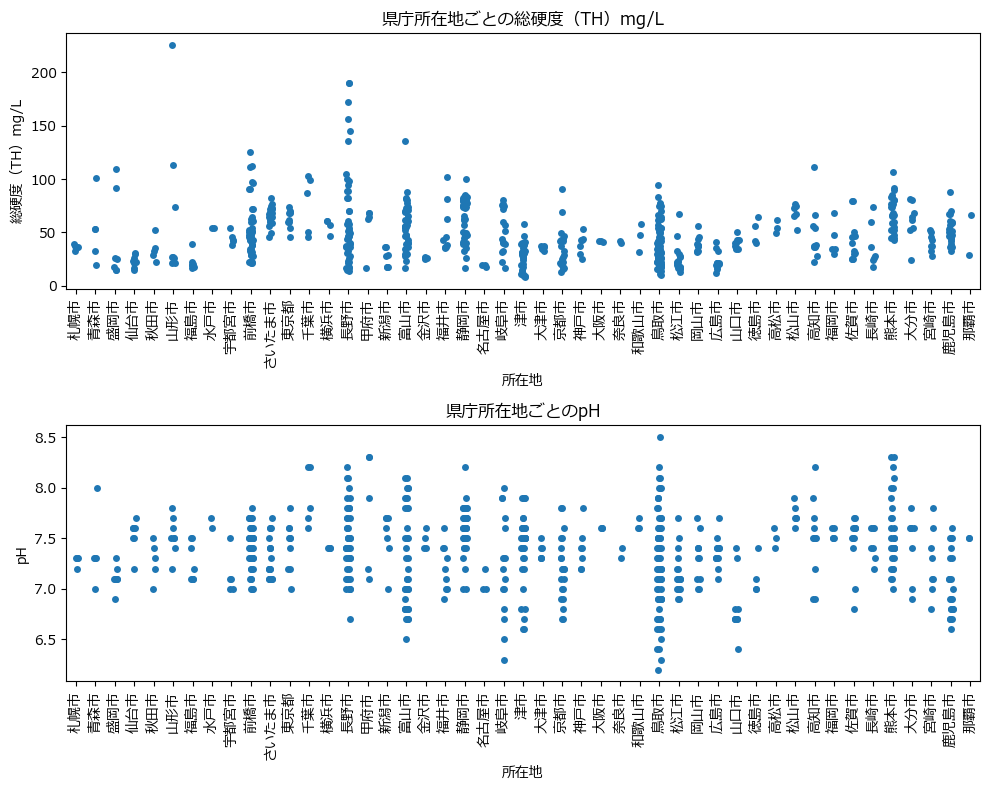

In [24]:
# 簡単に可視化して47都市の分布を比較してみる
### ジッタープロット

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.stripplot(
    ax=axes[0],
    data=df_water_quality,
    x="所在地",
    y="総硬度（TH）mg/L",
    jitter=True
)

sns.stripplot(
    ax=axes[1],
    data=df_water_quality,
    x="所在地",
    y="pH",
    jitter=True
)

axes[0].set_title("県庁所在地ごとの総硬度（TH）mg/L")
axes[1].set_title("県庁所在地ごとのpH")

#　ループで横軸の文字の回転を設定
for ax in axes:
    ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

グラフから、以下の集計項目を採用
#### 硬度
- 代表値：中央値（データにばらつきがある）
- 特徴　：最大値（中央値から最大硬度が突出している都市が多い）
- 　　　：最大値 - Q3 （多くのデータの値と突出したデータの差を表現）
#### pH
- 代表値：平均値（データが比較的まんべんなく分布）
- 特徴　：IQR　（データの半数が存在する範囲を表現）

In [39]:
# 集計
df_water_quality_summary = (
    df_water_quality
    .groupby("所在地")
    .agg(
        観測数=("所在地", "size"),
        hardness_median=("総硬度（TH）mg/L", "median"),
        hardness_max=("総硬度（TH）mg/L", "max"),
        ### 計算用
        hardness_q3=("総硬度（TH）mg/L", lambda x: x.quantile(0.75)),
        pH_mean=("pH", "mean"),
        pH_IQR=("pH", lambda x: x.quantile(0.75) - x.quantile(0.25))
    )
    .reset_index()
)

# Max-Q3の計算
df_water_quality_summary["hardness_max_minus_q3"] = (
    df_water_quality_summary["hardness_max"]
    - df_water_quality_summary["hardness_q3"]
)

# Q3はいらないので削除
df_water_quality_summary = df_water_quality_summary.drop(
    columns="hardness_q3"
)

df_water_quality_summary.head(2)

,所在地,観測数,hardness_median,hardness_max,pH_mean,pH_IQR,hardness_max_minus_q3
0,さいたま市,20,67.0,82,7.305,0.325,10.00
1,京都市,22,31.0,91,7.200,0.375,48.25


In [54]:
# 集計結果を県庁所在地データにマージ
df_analysis_water = df_analysis_water.merge(
    df_water_quality_summary,
    left_on="県庁所在地",
    right_on="所在地",
    how="left"
).drop(columns="所在地")
df_analysis_water.head(2)

,コード,都道府県,県庁所在地,ローマ字,河川,地下水,湧水,観測数,hardness_median,hardness_max,pH_mean,pH_IQR,hardness_max_minus_q3
0,1,北海道,札幌市,sapporo,1,0,0,5.0,36.0,39.0,7.28,0.0,2.0
1,2,青森県,青森市,aomori,1,0,0,5.0,53.0,101.0,7.38,0.0,48.0


### 【集計した値を可視化してみる】

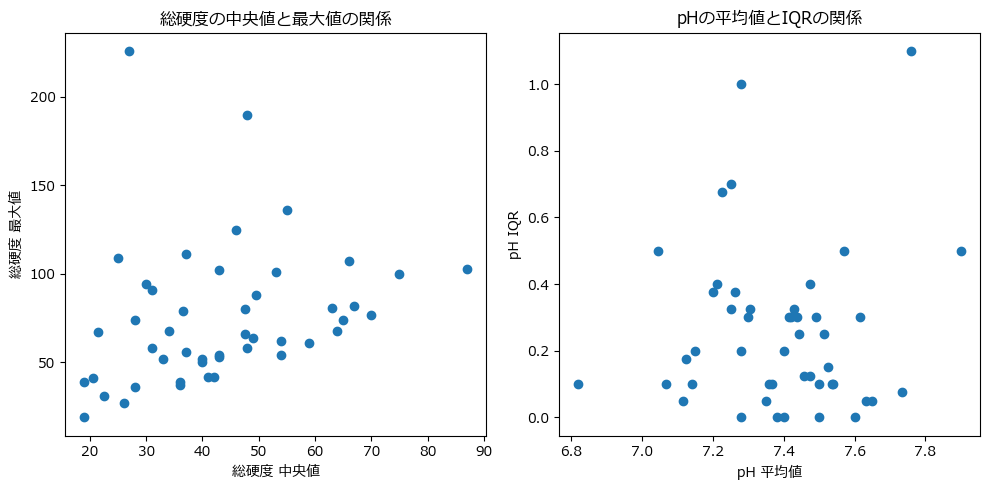

In [48]:
# 硬度・pHそれぞれの指標ごとに散布図
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ① 硬度中央値 × Max
axes[0].scatter(
    df_water_quality_summary["hardness_median"],
    df_water_quality_summary["hardness_max"]
)

axes[0].set_xlabel("総硬度 中央値")
axes[0].set_ylabel("総硬度 最大値")
axes[0].set_title("総硬度の中央値と最大値の関係")

# ② pH平均 × IQR
axes[1].scatter(
    df_water_quality_summary["pH_mean"],
    df_water_quality_summary["pH_IQR"]
)

axes[1].set_xlabel("pH 平均値")
axes[1].set_ylabel("pH IQR")
axes[1].set_title("pHの平均値とIQRの関係")

plt.tight_layout()
plt.show()

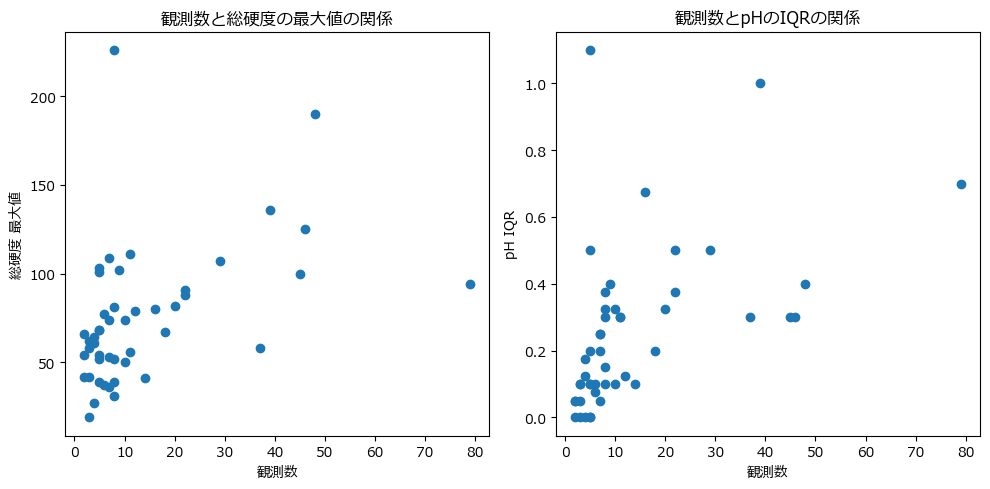

In [47]:
# 観測数に特徴の指標が引っ張られているか関係性チェック
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ① 硬度中央値 × Max
axes[0].scatter(
    df_water_quality_summary["観測数"],
    df_water_quality_summary["hardness_max"]
)

axes[0].set_xlabel("観測数")
axes[0].set_ylabel("総硬度 最大値")
axes[0].set_title("観測数と総硬度の最大値の関係")

# ② pH平均 × IQR
axes[1].scatter(
    df_water_quality_summary["観測数"],
    df_water_quality_summary["pH_IQR"]
)

axes[1].set_xlabel("観測数")
axes[1].set_ylabel("pH IQR")
axes[1].set_title("観測数とpHのIQRの関係")

plt.tight_layout()
plt.show()

In [57]:
# 集計結果出力
df_analysis_water.to_csv("../data/df_analysis_water.csv", encoding='shift_jis')

##### Viz候補
- 硬度とpHのジッタープロット
- 散布図　→　観測数との関係はプレゼンには載せてもいいけどVizにはいらないかな…？